In [1]:
import pandas as pd 
print("Python is working!") 

Python is working!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
df = pd.read_excel(r'C:\Users\bhagy\OneDrive\Documents\finance_project\personal_transactions_dashboard_ready (2).xlsx')

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print()
df.head()

Rows    : 806
Columns : 7



,Date,Description,Amount,Transaction Type,Category,Account Name,Month
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01
4,2018-01-04,Netflix,11.76,debit,Movies & Dvds,Platinum Card,2018-01


In [4]:
import subprocess
subprocess.run(['pip', 'install', 'openpyxl'], check=True)
print("✅ openpyxl installed!")

✅ openpyxl installed!


In [5]:
print("=== DATA TYPES ===")
print(df.dtypes)
print()
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print()
print("=== CATEGORIES ===")
print(df['Category'].unique())
print()
print("=== ACCOUNTS ===")
print(df['Account Name'].unique())

=== DATA TYPES ===
Date                datetime64[ns]
Description                 object
Amount                     float64
Transaction Type            object
Category                    object
Account Name                object
Month                       object
dtype: object

=== MISSING VALUES ===
Date                0
Description         0
Amount              0
Transaction Type    0
Category            0
Account Name        0
Month               0
dtype: int64

=== CATEGORIES ===
['Shopping' 'Mortgage & Rent' 'Restaurants' 'Credit Card Payment'
 'Movies & Dvds' 'Home Improvement' 'Utilities' 'Music' 'Mobile Phone'
 'Gas & Fuel' 'Groceries' 'Paycheck' 'Fast Food' 'Coffee Shops' 'Internet'
 'Haircut' 'Alcohol & Bars' 'Auto Insurance' 'Entertainment'
 'Food & Dining' 'Television' 'Electronics & Software']

=== ACCOUNTS ===
['Platinum Card' 'Checking' 'Silver Card']


In [6]:
# Convert Date to proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time columns from Date
df['Year']       = df['Date'].dt.year
df['MonthNum']   = df['Date'].dt.month
df['MonthLabel'] = df['Date'].dt.strftime('%b %Y')
df['YearMonth']  = df['Date'].dt.to_period('M')
df['DayOfWeek']  = df['Date'].dt.day_name()

# Separate expenses and income
expenses = df[df['Transaction Type'] == 'debit'].copy()
income   = df[df['Transaction Type'] == 'credit'].copy()

# Remove internal transfers from expenses
real_expenses = expenses[expenses['Category'] != 'Credit Card Payment'].copy()

print(f"Total rows         : {len(df)}")
print(f"Expense rows       : {len(expenses)}")
print(f"Income rows        : {len(income)}")
print(f"Real expenses rows : {len(real_expenses)}")
print()
print("✅ Data cleaned successfully!")

Total rows         : 806
Expense rows       : 688
Income rows        : 118
Real expenses rows : 617

✅ Data cleaned successfully!


In [7]:
# Total spending per category
cat_spend = (
    real_expenses
    .groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
)

print("=== TOTAL SPENDING BY CATEGORY ===")
for cat, amt in cat_spend.items():
    print(f"  {cat:<30} ${amt:>10,.2f}")

=== TOTAL SPENDING BY CATEGORY ===
  Mortgage & Rent                $ 24,754.50
  Home Improvement               $ 19,092.87
  Groceries                      $  2,795.21
  Utilities                      $  2,776.00
  Restaurants                    $  2,613.02
  Shopping                       $  1,973.24
  Gas & Fuel                     $  1,715.17
  Mobile Phone                   $  1,680.40
  Internet                       $  1,570.88
  Auto Insurance                 $  1,350.00
  Electronics & Software         $    719.00
  Alcohol & Bars                 $    539.13
  Haircut                        $    378.00
  Fast Food                      $    330.63
  Music                          $    224.49
  Movies & Dvds                  $    222.19
  Coffee Shops                   $    115.54
  Television                     $    104.78
  Food & Dining                  $     77.75
  Entertainment                  $      9.62


In [8]:
# Total spending per month
monthly = (
    real_expenses
    .groupby('YearMonth')['Amount']
    .sum()
    .sort_index()
)

print("=== MONTHLY SPENDING ===")
for month, amt in monthly.items():
    print(f"  {str(month):<12}  ${amt:>10,.2f}")

print()
print(f"  Highest spending month : {monthly.idxmax()} (${monthly.max():,.2f})")
print(f"  Lowest spending month  : {monthly.idxmin()} (${monthly.min():,.2f})")
print(f"  Average monthly spend  : ${monthly.mean():,.2f}")

=== MONTHLY SPENDING ===
  2018-01       $  2,066.65
  2018-02       $  2,089.44
  2018-03       $  2,178.66
  2018-04       $  2,862.66
  2018-05       $ 10,507.56
  2018-06       $  2,115.05
  2018-07       $  2,302.64
  2018-08       $  1,992.68
  2018-09       $  2,314.74
  2018-10       $  2,242.37
  2018-11       $  2,118.15
  2018-12       $  2,652.94
  2019-01       $  1,736.43
  2019-02       $  1,954.60
  2019-03       $  2,142.59
  2019-04       $  1,966.87
  2019-05       $  2,253.41
  2019-06       $ 10,912.38
  2019-07       $  2,551.12
  2019-08       $  2,043.20
  2019-09       $  2,038.28

  Highest spending month : 2019-06 ($10,912.38)
  Lowest spending month  : 2019-01 ($1,736.43)
  Average monthly spend  : $3,002.02


In [9]:
# Spending by account
acct_spend = (
    real_expenses
    .groupby('Account Name')['Amount']
    .sum()
    .sort_values(ascending=False)
)

# Key numbers
total_spent  = real_expenses['Amount'].sum()
total_income = income['Amount'].sum()
net          = total_income - total_spent

print("=" * 50)
print("       YOUR FINANCIAL SUMMARY")
print("=" * 50)
print(f"  Total spent (all time)  : ${total_spent:>10,.2f}")
print(f"  Total income            : ${total_income:>10,.2f}")
print(f"  Net (Income - Expense)  : ${net:>10,.2f}")
print(f"  Avg monthly spend       : ${monthly.mean():>10,.2f}")
print(f"  Top expense category    : {cat_spend.idxmax()}")
print(f"  Highest spending month  : {monthly.idxmax()}")
print(f"  Lowest spending month   : {monthly.idxmin()}")
print(f"  Most used account       : {acct_spend.idxmax()}")
print("=" * 50)

print()
print("=== SPENDING BY ACCOUNT ===")
for acct, amt in acct_spend.items():
    pct = (amt / acct_spend.sum()) * 100
    print(f"  {acct:<20} ${amt:>10,.2f}  ({pct:.1f}%)")

       YOUR FINANCIAL SUMMARY
  Total spent (all time)  : $ 63,042.42
  Total income            : $124,269.76
  Net (Income - Expense)  : $ 61,227.34
  Avg monthly spend       : $  3,002.02
  Top expense category    : Mortgage & Rent
  Highest spending month  : 2019-06
  Lowest spending month   : 2019-01
  Most used account       : Checking

=== SPENDING BY ACCOUNT ===
  Checking             $ 49,456.78  (78.5%)
  Platinum Card        $  8,996.31  (14.3%)
  Silver Card          $  4,589.33  (7.3%)


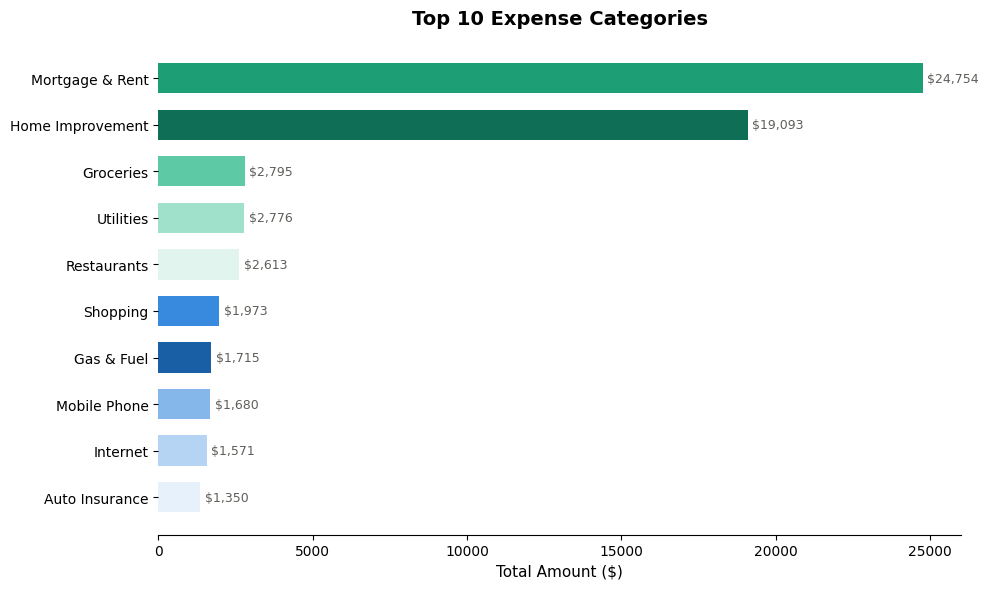

✅ Chart saved as chart1_top_categories.png


In [10]:
# Bar chart — Top 10 Expense Categories
fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    '#1D9E75','#0F6E56','#5DCAA5','#9FE1CB','#E1F5EE',
    '#378ADD','#185FA5','#85B7EB','#B5D4F4','#E6F1FB'
]
top10 = cat_spend.head(10)
ax.barh(top10.index[::-1], top10.values[::-1],
        color=colors[::-1], edgecolor='none', height=0.65)

for bar, val in zip(ax.patches, top10.values[::-1]):
    ax.text(bar.get_width() + 150,
            bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=9, color='#5F5E5A')

ax.set_title('Top 10 Expense Categories', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Amount ($)', fontsize=11)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig('chart1_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as chart1_top_categories.png")

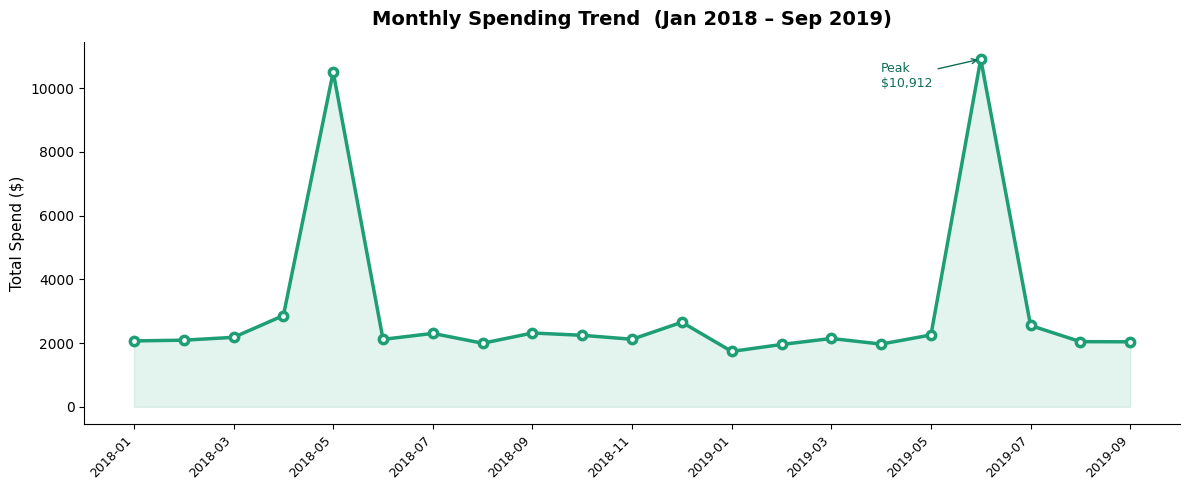

✅ Chart saved as chart2_monthly_trend.png


In [11]:
# Line chart — Monthly Spending Trend
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(monthly))
ax.plot(x, monthly.values, color='#1D9E75', linewidth=2.5,
        marker='o', markersize=6,
        markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(x, monthly.values, alpha=0.12, color='#1D9E75')

# Mark the peak month
peak_idx = list(monthly.values).index(monthly.max())
ax.annotate(f'Peak\n${monthly.max():,.0f}',
            xy=(peak_idx, monthly.max()),
            xytext=(peak_idx - 2, monthly.max() * 0.92),
            fontsize=9, color='#0F6E56',
            arrowprops=dict(arrowstyle='->', color='#0F6E56'))

step = max(1, len(monthly) // 8)
ax.set_xticks(list(x)[::step])
ax.set_xticklabels([str(m) for m in monthly.index[::step]],
                   rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Spending Trend  (Jan 2018 – Sep 2019)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Spend ($)', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as chart2_monthly_trend.png")

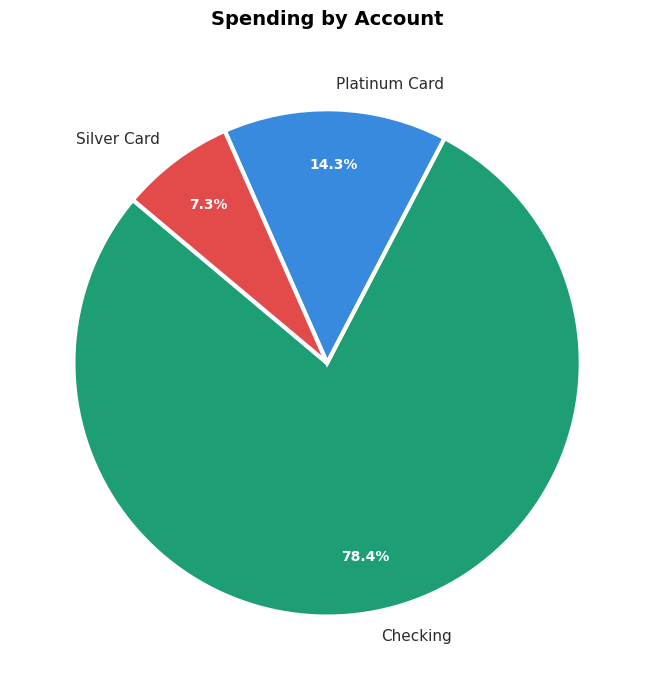

✅ Chart saved as chart3_account_pie.png


In [12]:
# Pie chart — Spending by Account
fig, ax = plt.subplots(figsize=(7, 7))

pie_colors = ['#1D9E75', '#378ADD', '#E24B4A']
wedges, texts, autotexts = ax.pie(
    acct_spend.values,
    labels=acct_spend.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=3)
)
for t in texts:
    t.set_fontsize(11)
    t.set_color('#2C2C2A')
for at in autotexts:
    at.set_fontsize(10)
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title('Spending by Account',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart3_account_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as chart3_account_pie.png")

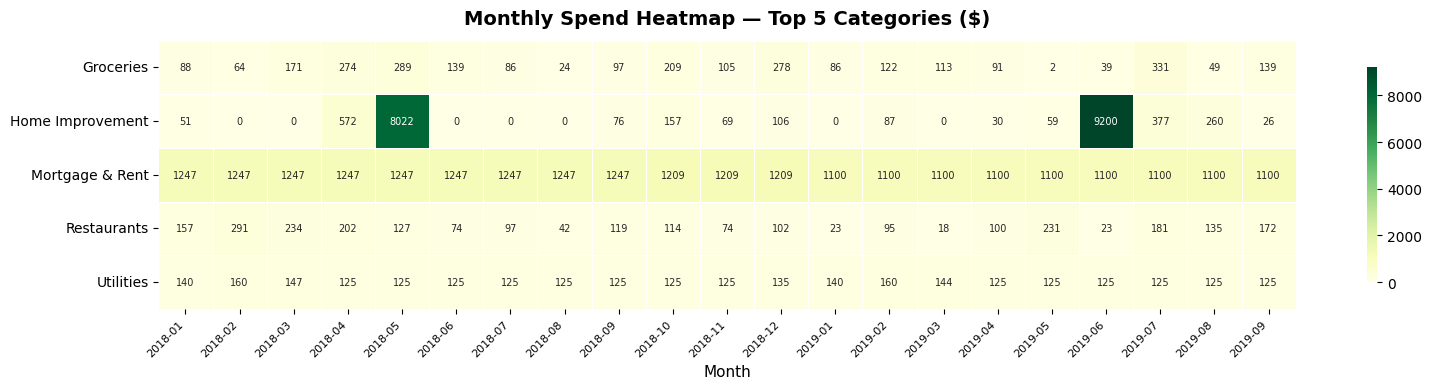

✅ Chart saved as chart4_heatmap.png


In [13]:
# Heatmap — Top 5 Categories Over Time
top5cats = cat_spend.index[:5].tolist()
hm = real_expenses[real_expenses['Category'].isin(top5cats)].copy()
hm['YM'] = hm['Date'].dt.to_period('M').astype(str)

pivot2 = hm.pivot_table(index='Category', columns='YM',
                         values='Amount', aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot2, ax=ax, cmap='YlGn',
            linewidths=0.4, linecolor='white',
            annot=True, fmt='.0f',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})

ax.set_title('Monthly Spend Heatmap — Top 5 Categories ($)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as chart4_heatmap.png")

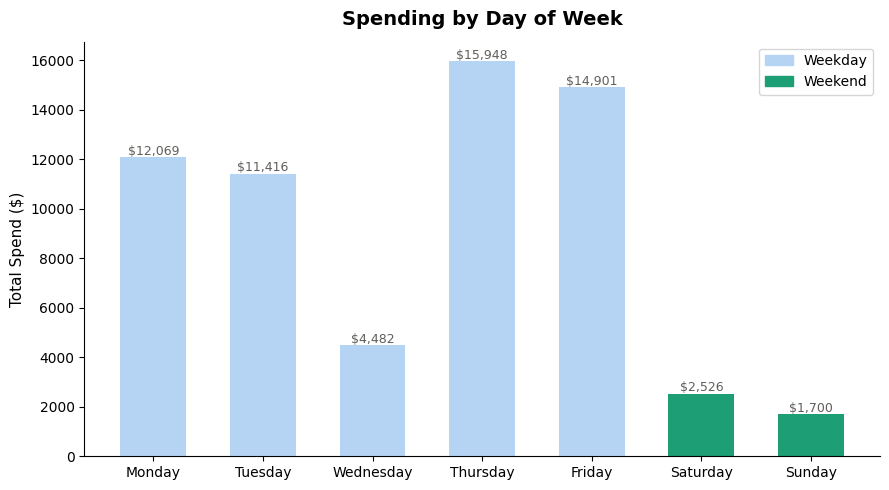

✅ Chart saved as chart5_day_of_week.png


In [14]:
# Bar chart — Spending by Day of Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_spend = (
    real_expenses.groupby('DayOfWeek')['Amount']
    .sum()
    .reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(9, 5))

# Weekdays in blue, weekends in green
bar_colors = ['#B5D4F4'] * 5 + ['#1D9E75'] * 2
ax.bar(dow_order, dow_spend.values,
       color=bar_colors, edgecolor='none', width=0.6)

for bar, val in zip(ax.patches, dow_spend.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'${val:,.0f}',
            ha='center', fontsize=9, color='#5F5E5A')

ax.set_title('Spending by Day of Week',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Spend ($)', fontsize=11)
ax.spines[['top','right']].set_visible(False)

weekday_patch = mpatches.Patch(color='#B5D4F4', label='Weekday')
weekend_patch = mpatches.Patch(color='#1D9E75', label='Weekend')
ax.legend(handles=[weekday_patch, weekend_patch], fontsize=10)

plt.tight_layout()
plt.savefig('chart5_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as chart5_day_of_week.png")

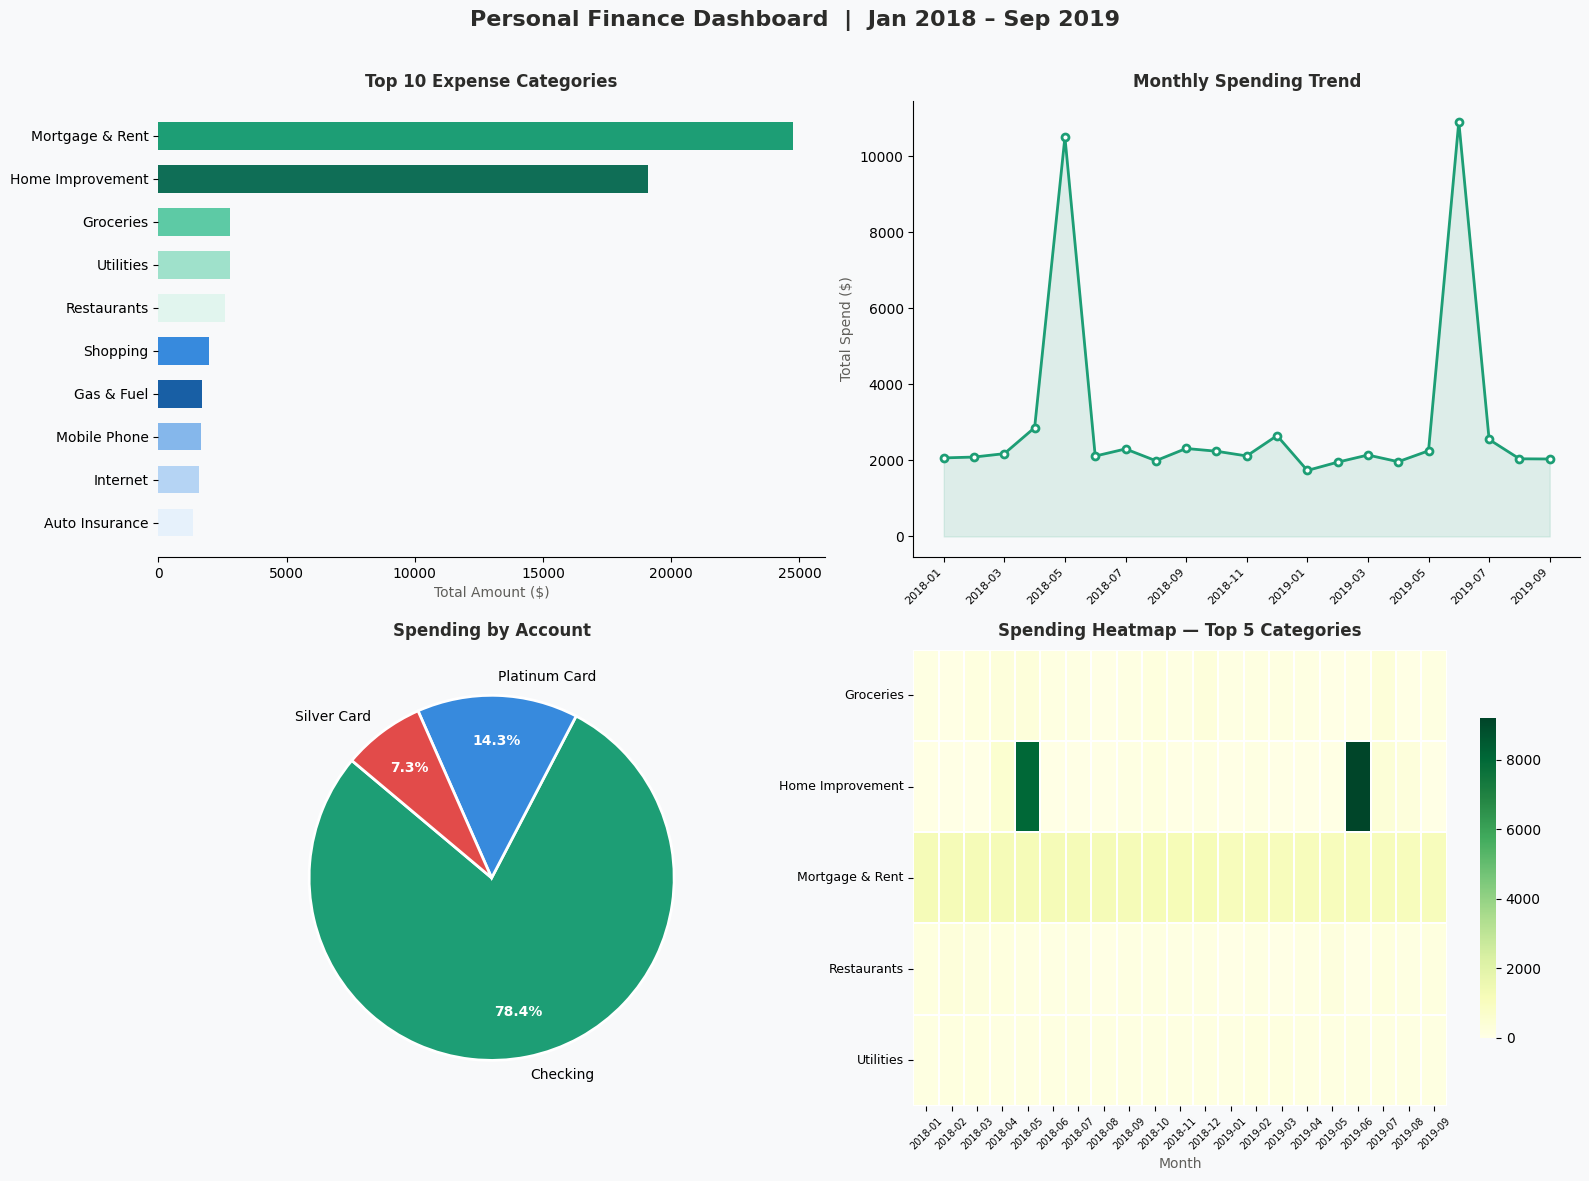

✅ Full dashboard saved as finance_dashboard.png


In [15]:
# Full 2x2 Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F8F9FA')
plt.suptitle('Personal Finance Dashboard  |  Jan 2018 – Sep 2019',
             fontsize=16, fontweight='bold', y=0.98, color='#2C2C2A')

# Chart 1 — Top 10 categories
chart_colors = ['#1D9E75','#0F6E56','#5DCAA5','#9FE1CB','#E1F5EE',
                '#378ADD','#185FA5','#85B7EB','#B5D4F4','#E6F1FB']
top10 = cat_spend.head(10)
axes[0,0].barh(top10.index[::-1], top10.values[::-1],
               color=chart_colors[::-1], edgecolor='none', height=0.65)
axes[0,0].set_title('Top 10 Expense Categories',
                    fontweight='bold', pad=10, color='#2C2C2A')
axes[0,0].set_xlabel('Total Amount ($)', color='#5F5E5A')
axes[0,0].spines[['top','right','left']].set_visible(False)
axes[0,0].set_facecolor('#F8F9FA')

# Chart 2 — Monthly trend
xm = range(len(monthly))
axes[0,1].plot(xm, monthly.values, color='#1D9E75', linewidth=2,
               marker='o', markersize=5,
               markerfacecolor='white', markeredgewidth=2)
axes[0,1].fill_between(xm, monthly.values, alpha=0.12, color='#1D9E75')
axes[0,1].set_title('Monthly Spending Trend',
                    fontweight='bold', pad=10, color='#2C2C2A')
axes[0,1].set_ylabel('Total Spend ($)', color='#5F5E5A')
step = max(1, len(monthly) // 8)
axes[0,1].set_xticks(list(xm)[::step])
axes[0,1].set_xticklabels([str(m) for m in monthly.index[::step]],
                           rotation=45, ha='right', fontsize=8)
axes[0,1].spines[['top','right']].set_visible(False)
axes[0,1].set_facecolor('#F8F9FA')

# Chart 3 — Pie by account
pie_colors = ['#1D9E75', '#378ADD', '#E24B4A']
wedges, texts, autotexts = axes[1,0].pie(
    acct_spend.values, labels=acct_spend.index,
    autopct='%1.1f%%', colors=pie_colors,
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
axes[1,0].set_title('Spending by Account',
                    fontweight='bold', pad=10, color='#2C2C2A')
axes[1,0].set_facecolor('#F8F9FA')

# Chart 4 — Heatmap
sns.heatmap(pivot2, ax=axes[1,1], cmap='YlGn',
            linewidths=0.3, linecolor='white',
            annot=False, cbar_kws={'shrink': 0.7})
axes[1,1].set_title('Spending Heatmap — Top 5 Categories',
                    fontweight='bold', pad=10, color='#2C2C2A')
axes[1,1].set_xlabel('Month', color='#5F5E5A')
axes[1,1].set_ylabel('')
axes[1,1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1,1].tick_params(axis='y', labelsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('finance_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ Full dashboard saved as finance_dashboard.png")

In [16]:
folder = r'C:\Users\bhagy\OneDrive\Documents\finance_project\\'

df2 = pd.read_csv(folder + 'Personal_Finance_Dataset.csv')
df3 = pd.read_csv(folder + 'personal_transactions.csv')
df4 = pd.read_excel(folder + 'personal finance data.xlsx')

print("=== FILE 2 — Personal_Finance_Dataset.csv ===")
print(f"Rows: {df2.shape[0]}  Columns: {df2.shape[1]}")
print("Columns:", df2.columns.tolist())
print()

print("=== FILE 3 — personal_transactions.csv ===")
print(f"Rows: {df3.shape[0]}  Columns: {df3.shape[1]}")
print("Columns:", df3.columns.tolist())
print()

print("=== FILE 4 — personal finance data.xlsx ===")
print(f"Rows: {df4.shape[0]}  Columns: {df4.shape[1]}")
print("Columns:", df4.columns.tolist())

print()
print("✅ All 3 files loaded successfully!")

=== FILE 2 — Personal_Finance_Dataset.csv ===
Rows: 1500  Columns: 5
Columns: ['Date', 'Transaction Description', 'Category', 'Amount', 'Type']

=== FILE 3 — personal_transactions.csv ===
Rows: 806  Columns: 6
Columns: ['Date', 'Description', 'Amount', 'Transaction Type', 'Category', 'Account Name']

=== FILE 4 — personal finance data.xlsx ===
Rows: 225  Columns: 6
Columns: ['Date / Time', 'Mode', 'Category', 'Sub category', 'Income/Expense', 'Debit/Credit']

✅ All 3 files loaded successfully!


In [17]:
import os

folder = r'C:\Users\bhagy\OneDrive\Documents\finance_project'
files = os.listdir(folder)

print("Files in your folder:")
for f in files:
    print(" -", f)

Files in your folder:
 - .ipynb_checkpoints
 - chart1_top_categories.png
 - chart2_monthly_trend.png
 - chart3_account_pie.png
 - chart4_heatmap.png
 - chart5_day_of_week.png
 - combined_chart1_top_categories.png
 - combined_chart2_monthly_trend.png
 - finance_analysis.ipynb
 - finance_dashboard.png
 - personal finance data.xlsx
 - Personal_Finance_Dataset.csv
 - personal_transactions.csv
 - personal_transactions_dashboard_ready (2).xlsx


In [18]:
# Standardise FILE 2 — Personal_Finance_Dataset.csv
df2_clean = pd.DataFrame()
df2_clean['Date']             = pd.to_datetime(df2['Date'])
df2_clean['Amount']           = df2['Amount']
df2_clean['Category']         = df2['Category'].str.strip().str.title()
df2_clean['Transaction Type'] = df2['Type'].str.lower()
df2_clean['Account Name']     = 'Unknown'
df2_clean['Source']           = 'File2'

# Standardise FILE 3 — personal_transactions.csv
df3_clean = pd.DataFrame()
df3_clean['Date']             = pd.to_datetime(df3['Date'])
df3_clean['Amount']           = df3['Amount']
df3_clean['Category']         = df3['Category'].str.strip().str.title()
df3_clean['Transaction Type'] = df3['Transaction Type'].str.lower()
df3_clean['Account Name']     = df3['Account Name']
df3_clean['Source']           = 'File3'

# Standardise FILE 4 — personal finance data.xlsx
df4_clean = pd.DataFrame()
df4_clean['Date']             = pd.to_datetime(df4['Date / Time'])
df4_clean['Amount']           = df4['Debit/Credit']
df4_clean['Category']         = df4['Category'].str.strip().str.title()
df4_clean['Transaction Type'] = df4['Income/Expense'].str.lower().replace({'income':'credit','expense':'debit'})
df4_clean['Account Name']     = df4['Mode']
df4_clean['Source']           = 'File4'

# Standardise FILE 1 — your main file (already cleaned)
df1_clean = real_expenses[['Date','Amount','Category','Transaction Type','Account Name']].copy()
df1_clean['Source'] = 'File1'

print("=== STANDARDISED ROW COUNTS ===")
print(f"  File 1 (main)                  : {len(df1_clean)} rows")
print(f"  File 2 (Personal_Finance)      : {len(df2_clean)} rows")
print(f"  File 3 (personal_transactions) : {len(df3_clean)} rows")
print(f"  File 4 (personal finance data) : {len(df4_clean)} rows")
print()
print("✅ All files standardised successfully!")

=== STANDARDISED ROW COUNTS ===
  File 1 (main)                  : 617 rows
  File 2 (Personal_Finance)      : 1500 rows
  File 3 (personal_transactions) : 806 rows
  File 4 (personal finance data) : 225 rows

✅ All files standardised successfully!


In [19]:
# Clean each file — keep only real expenses
df1_final = df1_clean[
    (df1_clean['Transaction Type'] == 'debit') &
    (df1_clean['Category'] != 'Credit Card Payment')
].copy()

df2_final = df2_clean[
    (df2_clean['Transaction Type'] == 'expense') &
    (df2_clean['Category'] != 'Credit Card Payment')
].copy()

df3_final = df3_clean[
    (df3_clean['Transaction Type'] == 'debit') &
    (df3_clean['Category'] != 'Credit Card Payment')
].copy()

df4_final = df4_clean[
    (df4_clean['Transaction Type'] == 'debit') &
    (df4_clean['Category'] != 'Credit Card Payment')
].copy()

# Combine all 4 into one big table
combined = pd.concat([df1_final, df2_final, df3_final, df4_final],
                     ignore_index=True)

# Extract time columns
combined['Year']      = combined['Date'].dt.year
combined['YearMonth'] = combined['Date'].dt.to_period('M')
combined['DayOfWeek'] = combined['Date'].dt.day_name()

print("=== CLEANED ROW COUNTS ===")
print(f"  File 1 : {len(df1_final)} rows")
print(f"  File 2 : {len(df2_final)} rows")
print(f"  File 3 : {len(df3_final)} rows")
print(f"  File 4 : {len(df4_final)} rows")
print(f"  Total  : {len(combined)} rows")
print()
print("✅ All files cleaned and combined successfully!")
combined.head()

=== CLEANED ROW COUNTS ===
  File 1 : 617 rows
  File 2 : 1222 rows
  File 3 : 617 rows
  File 4 : 182 rows
  Total  : 2638 rows

✅ All files cleaned and combined successfully!


,Date,Amount,Category,Transaction Type,Account Name,Source,Year,YearMonth,DayOfWeek
0,2018-01-01,11.11,Shopping,debit,Platinum Card,File1,2018,2018-01,Monday
1,2018-01-02,1247.44,Mortgage & Rent,debit,Checking,File1,2018,2018-01,Tuesday
2,2018-01-02,24.22,Restaurants,debit,Silver Card,File1,2018,2018-01,Tuesday
3,2018-01-04,11.76,Movies & Dvds,debit,Platinum Card,File1,2018,2018-01,Thursday
4,2018-01-05,25.85,Restaurants,debit,Silver Card,File1,2018,2018-01,Friday


In [20]:
# Key metrics from combined data
combined_cat   = combined.groupby('Category')['Amount'].sum().sort_values(ascending=False)
combined_monthly = combined.groupby('YearMonth')['Amount'].sum().sort_index()
combined_acct  = combined.groupby('Account Name')['Amount'].sum().sort_values(ascending=False)

print("=" * 55)
print("     COMBINED DATASET — FINANCIAL SUMMARY")
print("=" * 55)
print(f"  Total transactions  : {len(combined)}")
print(f"  Total spent         : ${combined['Amount'].sum():>12,.2f}")
print(f"  Average per txn     : ${combined['Amount'].mean():>12,.2f}")
print(f"  Avg monthly spend   : ${combined_monthly.mean():>12,.2f}")
print(f"  Top category        : {combined_cat.idxmax()}")
print(f"  Highest month       : {combined_monthly.idxmax()}")
print(f"  Lowest month        : {combined_monthly.idxmin()}")
print(f"  Most used account   : {combined_acct.idxmax()}")
print("=" * 55)

print()
print("=== TOP 10 CATEGORIES (COMBINED) ===")
for cat, amt in combined_cat.head(10).items():
    print(f"  {cat:<30} ${amt:>10,.2f}")

     COMBINED DATASET — FINANCIAL SUMMARY
  Total transactions  : 2638
  Total spent         : $1,503,132.49
  Average per txn     : $      569.80
  Avg monthly spend   : $   18,557.19
  Top category        : Travel
  Highest month       : 2021-04
  Lowest month        : 2019-01
  Most used account   : Unknown

=== TOP 10 CATEGORIES (COMBINED) ===
  Travel                         $169,497.79
  Rent                           $162,075.39
  Food & Drink                   $159,493.39
  Utilities                      $152,385.97
  Shopping                       $150,827.23
  Salary                         $149,053.55
  Entertainment                  $148,184.71
  Health & Fitness               $145,194.06
  Household                      $ 54,810.00
  Mortgage & Rent                $ 49,509.00


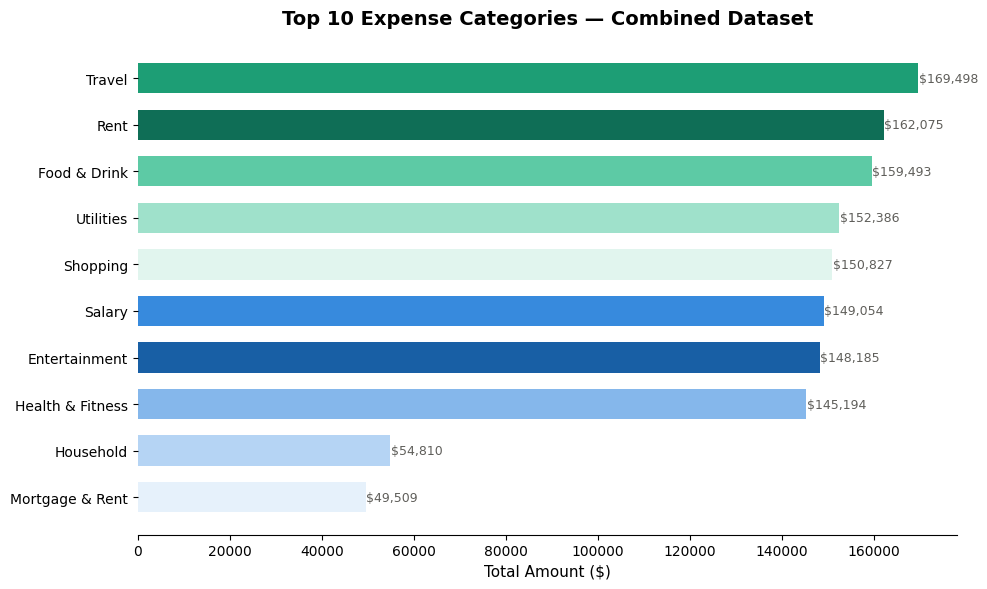

✅ Saved as combined_chart1_top_categories.png


In [21]:
# Bar chart — Top 10 Categories (Combined Dataset)
fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    '#1D9E75','#0F6E56','#5DCAA5','#9FE1CB','#E1F5EE',
    '#378ADD','#185FA5','#85B7EB','#B5D4F4','#E6F1FB'
]
top10_combined = combined_cat.head(10)
ax.barh(top10_combined.index[::-1], top10_combined.values[::-1],
        color=colors[::-1], edgecolor='none', height=0.65)

for bar, val in zip(ax.patches, top10_combined.values[::-1]):
    ax.text(bar.get_width() + 150,
            bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=9, color='#5F5E5A')

ax.set_title('Top 10 Expense Categories — Combined Dataset',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Amount ($)', fontsize=11)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig('combined_chart1_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as combined_chart1_top_categories.png")

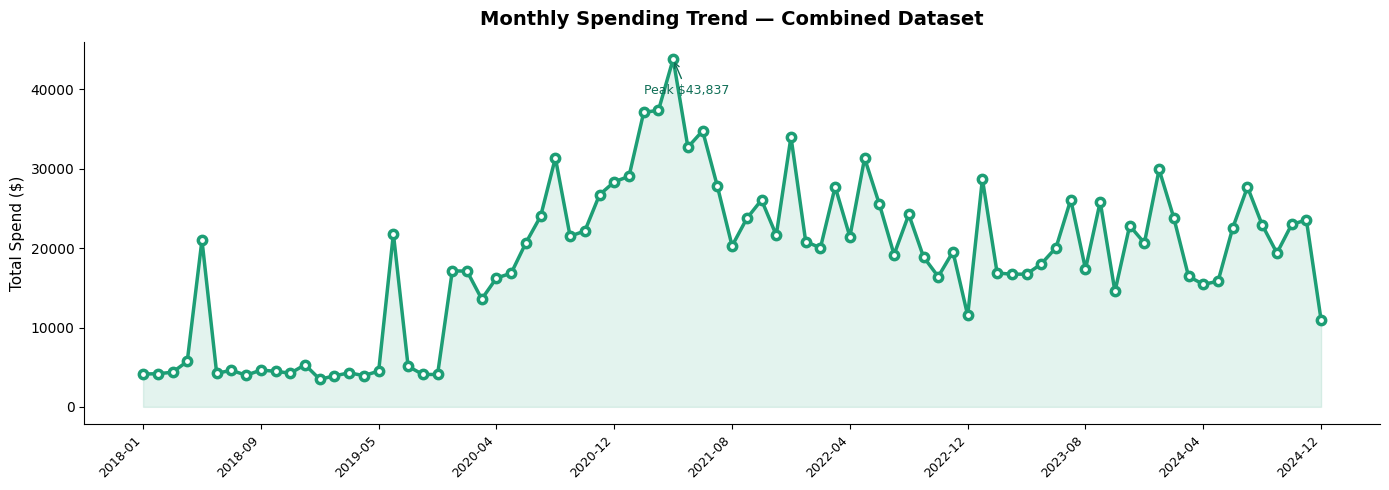

✅ Saved as combined_chart2_monthly_trend.png


In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(combined_monthly))
ax.plot(x, combined_monthly.values, color='#1D9E75', linewidth=2.5,
        marker='o', markersize=6,
        markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(x, combined_monthly.values, alpha=0.12, color='#1D9E75')

peak_idx = list(combined_monthly.values).index(combined_monthly.max())
ax.annotate(f'Peak ${combined_monthly.max():,.0f}',
            xy=(peak_idx, combined_monthly.max()),
            xytext=(peak_idx - 2, combined_monthly.max() * 0.90),
            fontsize=9, color='#0F6E56',
            arrowprops=dict(arrowstyle='->', color='#0F6E56'))

step = max(1, len(combined_monthly) // 10)
ax.set_xticks(list(x)[::step])
ax.set_xticklabels([str(m) for m in combined_monthly.index[::step]],
                   rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Spending Trend — Combined Dataset',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Spend ($)', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('combined_chart2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as combined_chart2_monthly_trend.png")

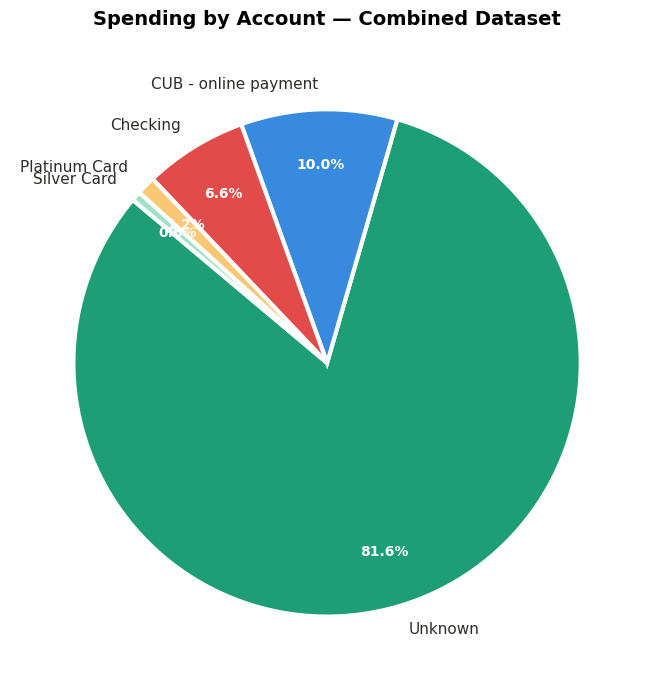

✅ Saved as combined_chart3_account_pie.png


In [23]:
# Pie chart — Spending by Account (Combined Dataset)
fig, ax = plt.subplots(figsize=(7, 7))

pie_colors = ['#1D9E75','#378ADD','#E24B4A','#FAC775','#9FE1CB']
wedges, texts, autotexts = ax.pie(
    combined_acct.values,
    labels=combined_acct.index,
    autopct='%1.1f%%',
    colors=pie_colors[:len(combined_acct)],
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=3)
)
for t in texts:
    t.set_fontsize(11)
    t.set_color('#2C2C2A')
for at in autotexts:
    at.set_fontsize(10)
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title('Spending by Account — Combined Dataset',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('combined_chart3_account_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as combined_chart3_account_pie.png")

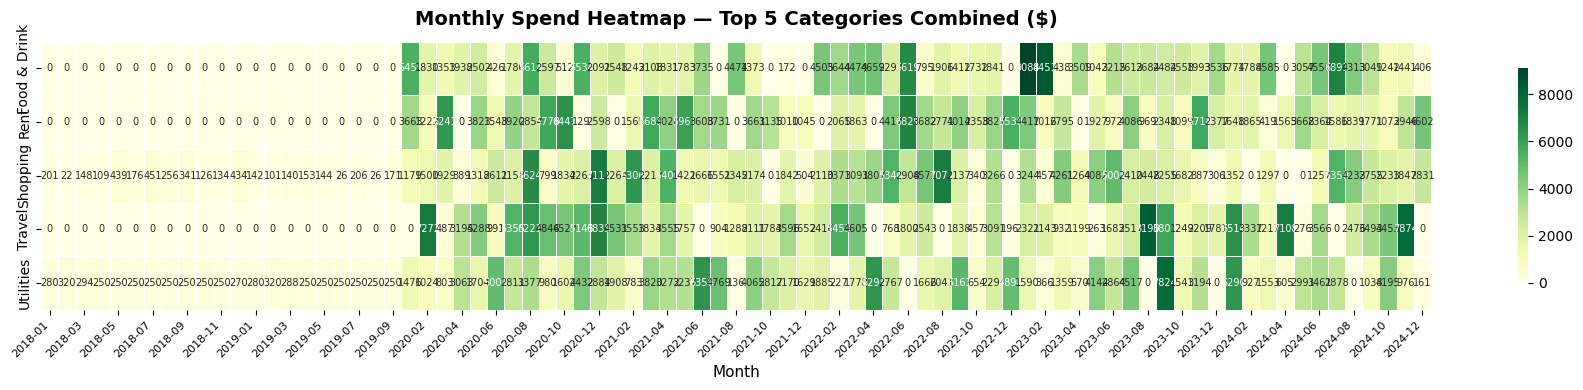

✅ Saved as combined_chart4_heatmap.png


In [25]:
# Heatmap — Top 5 Categories Over Time (Combined Dataset)
top5_combined = combined_cat.index[:5].tolist()
hm2 = combined[combined['Category'].isin(top5_combined)].copy()
hm2['YM'] = hm2['Date'].dt.to_period('M').astype(str)

pivot3 = hm2.pivot_table(index='Category', columns='YM',
                          values='Amount', aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(pivot3, ax=ax, cmap='YlGn',
            linewidths=0.4, linecolor='white',
            annot=True, fmt='.0f',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})

ax.set_title('Monthly Spend Heatmap — Top 5 Categories Combined ($)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('combined_chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as combined_chart4_heatmap.png")

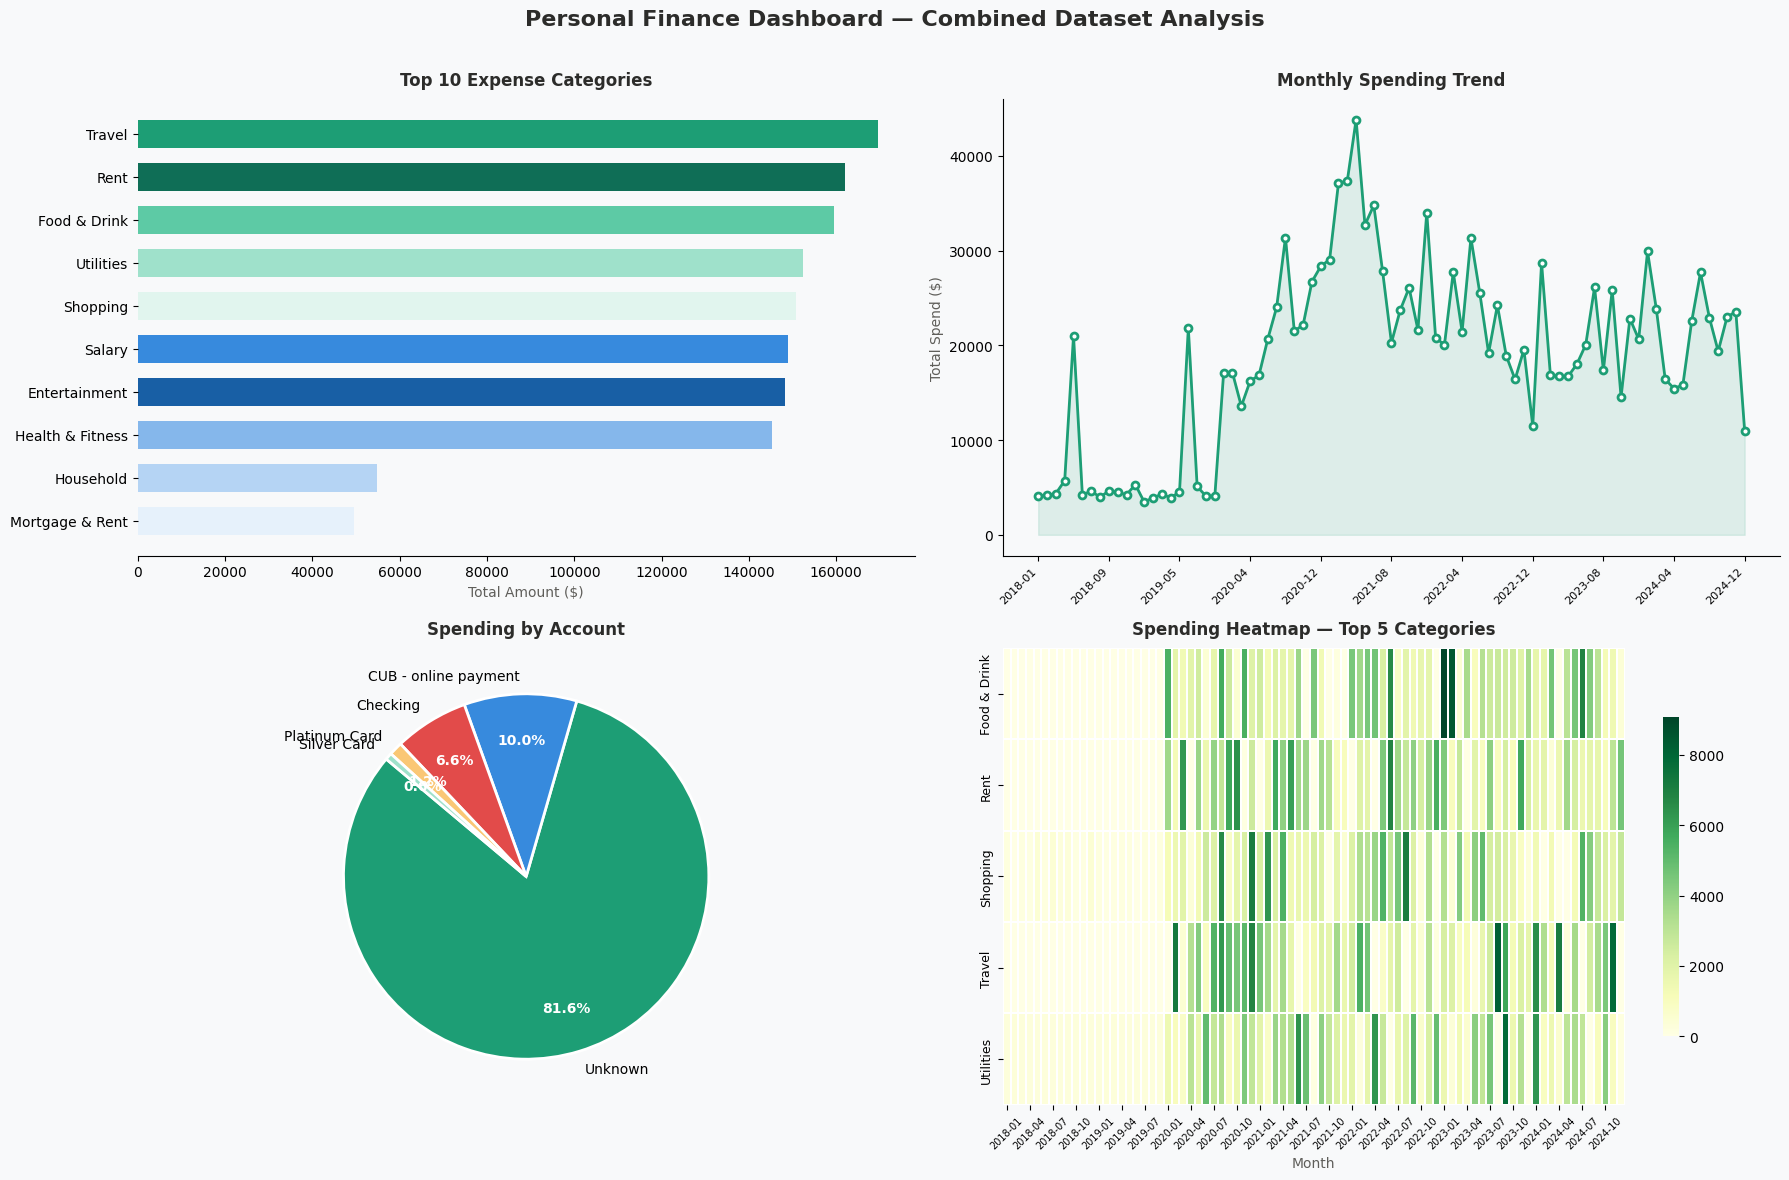

✅ Final combined dashboard saved as combined_finance_dashboard.png


In [26]:
# Full Combined Dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor('#F8F9FA')
plt.suptitle('Personal Finance Dashboard — Combined Dataset Analysis',
             fontsize=16, fontweight='bold', y=0.98, color='#2C2C2A')

# Chart 1 — Top 10 categories
chart_colors = ['#1D9E75','#0F6E56','#5DCAA5','#9FE1CB','#E1F5EE',
                '#378ADD','#185FA5','#85B7EB','#B5D4F4','#E6F1FB']
top10_c = combined_cat.head(10)
axes[0,0].barh(top10_c.index[::-1], top10_c.values[::-1],
               color=chart_colors[::-1], edgecolor='none', height=0.65)
axes[0,0].set_title('Top 10 Expense Categories',
                    fontweight='bold', pad=10, color='#2C2C2A')
axes[0,0].set_xlabel('Total Amount ($)', color='#5F5E5A')
axes[0,0].spines[['top','right','left']].set_visible(False)
axes[0,0].set_facecolor('#F8F9FA')

# Chart 2 — Monthly trend
xm = range(len(combined_monthly))
axes[0,1].plot(xm, combined_monthly.values, color='#1D9E75',
               linewidth=2, marker='o', markersize=5,
               markerfacecolor='white', markeredgewidth=2)
axes[0,1].fill_between(xm, combined_monthly.values,
                        alpha=0.12, color='#1D9E75')
axes[0,1].set_title('Monthly Spending Trend',
                    fontweight='bold', pad=10, color='#2C2C2A')
axes[0,1].set_ylabel('Total Spend ($)', color='#5F5E5A')
step = max(1, len(combined_monthly) // 10)
axes[0,1].set_xticks(list(xm)[::step])
axes[0,1].set_xticklabels([str(m) for m in combined_monthly.index[::step]],
                           rotation=45, ha='right', fontsize=8)
axes[0,1].spines[['top','right']].set_visible(False)
axes[0,1].set_facecolor('#F8F9FA')

# Chart 3 — Pie by account
pie_colors = ['#1D9E75','#378ADD','#E24B4A','#FAC775','#9FE1CB']
wedges, texts, autotexts = axes[1,0].pie(
    combined_acct.values,
    labels=combined_acct.index,
    autopct='%1.1f%%',
    colors=pie_colors[:len(combined_acct)],
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
axes[1,0].set_title('Spending by Account',
                    fontweight='bold', pad=10, color='#2C2C2A')
axes[1,0].set_facecolor('#F8F9FA')

# Chart 4 — Heatmap
sns.heatmap(pivot3, ax=axes[1,1], cmap='YlGn',
            linewidths=0.3, linecolor='white',
            annot=False, cbar_kws={'shrink': 0.7})
axes[1,1].set_title('Spending Heatmap — Top 5 Categories',
                    fontweight='bold', pad=10, color='#2C2C2A')
axes[1,1].set_xlabel('Month', color='#5F5E5A')
axes[1,1].set_ylabel('')
axes[1,1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1,1].tick_params(axis='y', labelsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('combined_finance_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ Final combined dashboard saved as combined_finance_dashboard.png")